In [13]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

## Lab 2: Image Stitching with Homographies

In this lab, we will explore image stitching and panorama creation. You will use a homography to register two images together, and implement bilinear interpolation to help accomplish this. As part of the lab, you will also explore image enhancement strategies to improve the quality of image stitching at the seam (the join between two images) relying on your knowledge of image brightness and human perception of this. Collectively, tasks 1-5 will provide a final stitched image. In task 6, you will apply the same code written in tasks 1-5 to create a panorama image using your own photos.

* Task 1: Draw test points on the left image
* Task 2: Use a homography to find the location of these points in the right image
* Task 3: Bilinear interpolation of the right image pixels
* Task 4: Image stitching 
* Task 5: Better blending
* Task 6: Now try your own!

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

# Task 1: Draw test points on the left image

Draw the following points on the left image as red crosses. Display the resulting image.

{446 , 499, 1}, {383, 590, 1}, {296 , 499, 1}, {282, 511, 1}, {401 , 508, 1}

Recall from lectures that these 3-element homogeneous coordinates can be transformed to 2D image pixel coordinates by dividing the first and second elements by the third (needed for later tasks).

Task 1 left image points (x, y):
[[446. 499.]
 [383. 590.]
 [296. 499.]
 [282. 511.]
 [401. 508.]]


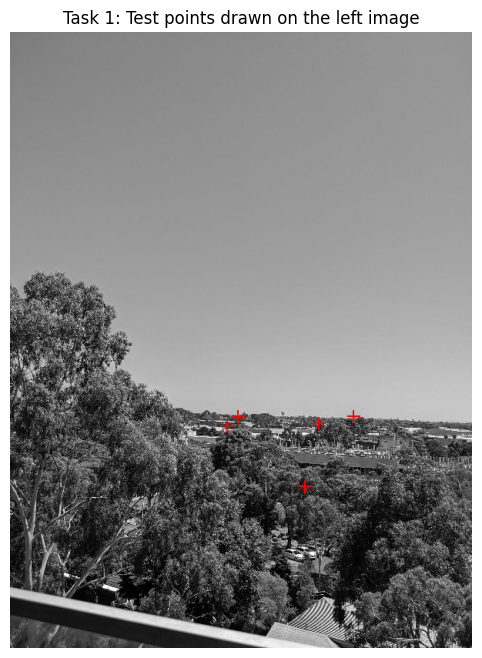

In [ ]:
import os
def gray_image(possible_paths):
    for path in possible_paths:
        if os.path.exists(path):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                return img
    raise FileNotFoundError(f"Could not find any of these files: {possible_paths}")

left_img = gray_image(['left.jpg', '/mnt/data/left.jpg'])
right_img = gray_image(['right.jpg', '/mnt/data/right.jpg'])

def from_homogeneous(points_h):
    points_h = np.asarray(points_h, dtype=np.float64)
    return points_h[:, :2] / points_h[:, 2:3]

def draw_crosses(gray_img, points_xy, color=(255, 0, 0), size=8, thickness=1):
    img_rgb = np.dstack([gray_img, gray_img, gray_img]).copy()
    h, w = gray_img.shape

    for pt in points_xy:
        x = int(round(pt[0]))
        y = int(round(pt[1]))

        for t in range(-thickness // 2, thickness // 2 + 1):
            for k in range(-size, size + 1):
                yy = y + k
                xx = x + t
                if 0 <= yy < h and 0 <= xx < w:
                    img_rgb[yy, xx] = color

                yy = y + t
                xx = x + k
                if 0 <= yy < h and 0 <= xx < w:
                    img_rgb[yy, xx] = color

    return img_rgb

Lpoint_h = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
], dtype=np.float64)

Lpoint_xy = from_homogeneous(Lpoint_h)
L_point = draw_crosses(left_img, Lpoint_xy)

print("Task 1 left image points (x, y):")
print(Lpoint_xy)

plt.figure(figsize=(8, 8))
plt.imshow(L_point)
plt.title('Task 1: Test points drawn on the left image')
plt.axis('off')
plt.show()

In [3]:
# Show results here

# Task 2: Use Homography to find right image points


The following homography transforms pixel coordinates between the left and right images as
$$ x_R = H x_L $$

\begin{bmatrix}
1.6011 & 0.0277 & -393.5701 \\
0.3242 & 1.5119 & -228.8918 \\
0.0009 & 0.0002 & 1.0000
\end{bmatrix}

Apply the homography to transform the left image points in Task 1 to their corresponding locations in the right image. Draw the transformed points as red crosses on the right image. Check your result before moving on.


Task 2 transformed points in the right image (homogeneous):
[[334.3428 670.1395   1.5012]
 [235.9942 787.2978   1.4627]
 [ 94.1778 621.5095   1.3662]
 [ 72.0948 635.1135   1.356 ]
 [262.5426 669.1576   1.4625]]

Task 2 transformed points in the right image (x, y):
Point 1: (222.7170, 446.4025)
Point 2: (161.3415, 538.2497)
Point 3: (68.9341, 454.9184)
Point 4: (53.1673, 468.3728)
Point 5: (179.5163, 457.5437)


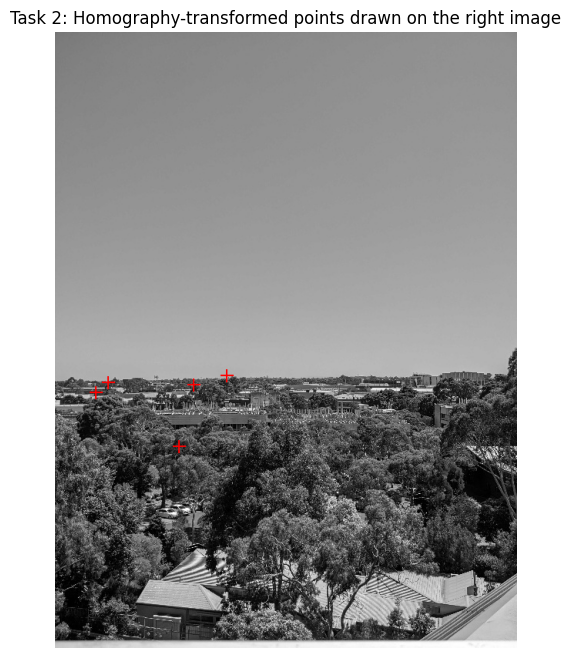

In [ ]:
# Write your code here

H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002, 1.0000]
], dtype=np.float64)

def apply_homography(H, points_h):
    points_h = np.asarray(points_h, dtype=np.float64)
    transformed_h = (H @ points_h.T).T
    transformed_xy = from_homogeneous(transformed_h)
    return transformed_h, transformed_xy

right_points_h, right_points_xy = apply_homography(H, Lpoint_h)
right_with_points = draw_crosses(right_img, right_points_xy)

print("Task 2 transformed points in the right image (homogeneous):")
print(right_points_h)

print("\nTask 2 transformed points in the right image (x, y):")
for i, pt in enumerate(right_points_xy, start=1):
    print(f"Point {i}: ({pt[0]:.4f}, {pt[1]:.4f})")

plt.figure(figsize=(8, 8))
plt.imshow(right_with_points)
plt.title('Task 2: Homography-transformed points drawn on the right image')
plt.axis('off')
plt.show()

In [5]:
# Print results here


# Task 3: Bilinear interpolation of the right image

The transformed coordinates can be in between pixel locations. Write a bilinear interpolation function to compute the intensity of the transformed pixel coordinate in right.jpg using intensity values from neighbouring pixel locations. Print the interpolated intensity value for each transformed point in Task 2. The first point should be around 176 whereas the last point should be around 73.

HINT: The bilinear interpolation function should take the transformed pixel coordinate and the intensity values of its four neighbours as input arguments, and should output the interpolated intensity value.

In [15]:
# Write your code here

def bilinear_neighbours(x, y, x0, y0, I00, I10, I01, I11):
    dx = x - x0
    dy = y - y0

    top = (1 - dx) * I00 + dx * I10
    bottom = (1 - dx) * I01 + dx * I11
    return (1 - dy) * top + dy * bottom

def bilinear_sample(img, x, y):
    h, w = img.shape

    if x < 0 or x >= w - 1 or y < 0 or y >= h - 1:
        return None

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    I00 = float(img[y0,     x0    ])
    I10 = float(img[y0,     x0 + 1])
    I01 = float(img[y0 + 1, x0    ])
    I11 = float(img[y0 + 1, x0 + 1])

    return bilinear_neighbours(x, y, x0, y0, I00, I10, I01, I11)

interpolated_values = []
for pt in right_points_xy:
    x, y = pt
    interpolated_values.append(bilinear_sample(right_img, x, y))

print("Task 3 bilinear interpolation results:")
for i, (pt, val) in enumerate(zip(right_points_xy, interpolated_values), start=1):
    print(f"Point {i}: x = {pt[0]:.4f}, y = {pt[1]:.4f}, interpolated intensity = {val:.4f}")

print("\nCheck against the lab sheet:")
print(f"First point intensity  = {interpolated_values[0]:.4f}  (should be about 176)")
print(f"Last point intensity   = {interpolated_values[-1]:.4f} (should be about 73)")

Task 3 bilinear interpolation results:
Point 1: x = 222.7170, y = 446.4025, interpolated intensity = 176.0000
Point 2: x = 161.3415, y = 538.2497, interpolated intensity = 38.4658
Point 3: x = 68.9341, y = 454.9184, interpolated intensity = 69.8289
Point 4: x = 53.1673, y = 468.3728, interpolated intensity = 58.1900
Point 5: x = 179.5163, y = 457.5437, interpolated intensity = 74.5071

Check against the lab sheet:
First point intensity  = 176.0000  (should be about 176)
Last point intensity   = 74.5071 (should be about 73)


In [7]:
# Show results here






# Task 4: Image stitching

Create a 1200x800 (width x height) image and fill the left hand side of this image with the left image. This stitched image will use the left image coordinate system (xl) throughout the stitching process. Next, fill in the remaining pixels on the RHS by transforming their pixel coordinates (left image coordinates) to the right image coordinates via the homography from Task 2 and determining the intensity using your bilinear interpolation implementation. If the right pixel  coordinate is valid, generate the pixel value using bilinear interpolation, but if the right pixel coordinate is invalid, use a pixel value of zero. Display the stitching results. It should look like a wide-angle image with a visible seam where the two images join.

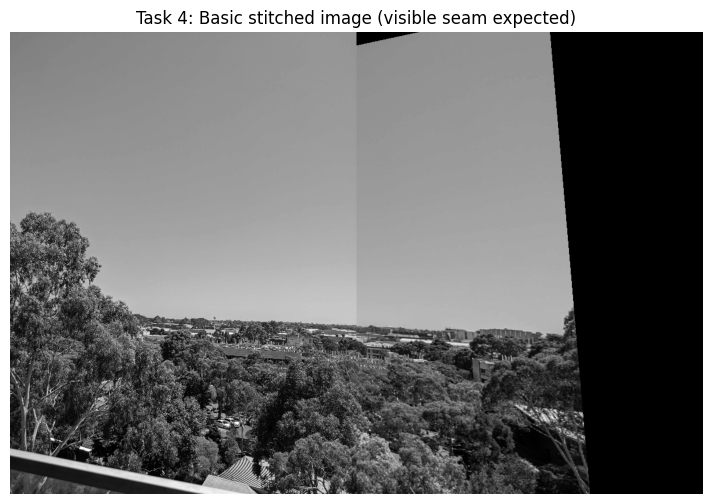

In [ ]:
# Write your code here

def bilinear_eg_vect(img, x, y):
    h, w = img.shape
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = (x >= 0) & (x < w - 1) & (y >= 0) & (y < h - 1)
    out = np.zeros_like(x, dtype=np.float64)

    if not np.any(valid):
        return out, valid

    xv = x[valid]
    yv = y[valid]

    x0 = np.floor(xv).astype(int)
    y0 = np.floor(yv).astype(int)

    dx = xv - x0
    dy = yv - y0

    I00 = img[y0,     x0    ].astype(np.float64)
    I10 = img[y0,     x0 + 1].astype(np.float64)
    I01 = img[y0 + 1, x0    ].astype(np.float64)
    I11 = img[y0 + 1, x0 + 1].astype(np.float64)

    out_valid = ((1 - dx) * (1 - dy) * I00 +
                 dx * (1 - dy) * I10 +
                 (1 - dx) * dy * I01 +
                 dx * dy * I11)

    out[valid] = out_valid
    return out, valid

def R_to_L_coords(right_img, H_left_to_right, output_width, output_height):
    xs, ys = np.meshgrid(np.arange(output_width), np.arange(output_height))

    denom = H_left_to_right[2, 0] * xs + H_left_to_right[2, 1] * ys + H_left_to_right[2, 2]
    x_right = (H_left_to_right[0, 0] * xs + H_left_to_right[0, 1] * ys + H_left_to_right[0, 2]) / denom
    y_right = (H_left_to_right[1, 0] * xs + H_left_to_right[1, 1] * ys + H_left_to_right[1, 2]) / denom

    warped_values, valid_mask = bilinear_eg_vect(right_img, x_right, y_right)
    warped_img = warped_values.reshape(output_height, output_width)
    valid_mask = valid_mask.reshape(output_height, output_width)

    return warped_img, valid_mask

output_width = 1200
output_height = 800

stitched_basic = np.zeros((output_height, output_width), dtype=np.float64)

left_h, left_w = left_img.shape
stitched_basic[:left_h, :left_w] = left_img

warped_right, valid_right = R_to_L_coords(right_img, H, output_width, output_height)

rhs_mask = np.zeros_like(valid_right)
rhs_mask[:, left_w:] = valid_right[:, left_w:]
stitched_basic[rhs_mask] = warped_right[rhs_mask]

stitched_basic = np.clip(stitched_basic, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.imshow(stitched_basic, cmap='gray')
plt.title('Task 4: Basic stitched image')
plt.axis('off');
plt.show()

In [9]:
# Show results here


# Task 5: Better blending

Improve the visual quality of the stitched image by trying the following image processing techniques:

1. Adjust the width of the output image automatically so that fewer black pixels are
visible 
2. Adjust the brightness (by a scaling factor) of each image so that the seam is less
visible
3. Apply a small amount of Gaussian blur or alpha blending near the seam to make
it less visible
4. Adjust the horizontal location of the seam (it can be moved further to the left as
the right image overlaps into the left by quite a few pixels)

Note that you do not have to try all of the above. However, you will only receive a mark here depending on
• the quality of the stitched image
• whether a serious programming attempt is made to improve the visual quality of the stitched image

Task 5 blending information:
auto_width: 1028
final_width: 1004
brightness_scale: 1.0581228633392614
seam_x: 252
blend_width: 80
projected_corners_in_left_coords: [[ 244.09867649   99.05086916]
 [ 930.44990149  -48.12491439]
 [ 231.49037639  827.82882156]
 [1026.55331631 1060.03824023]]


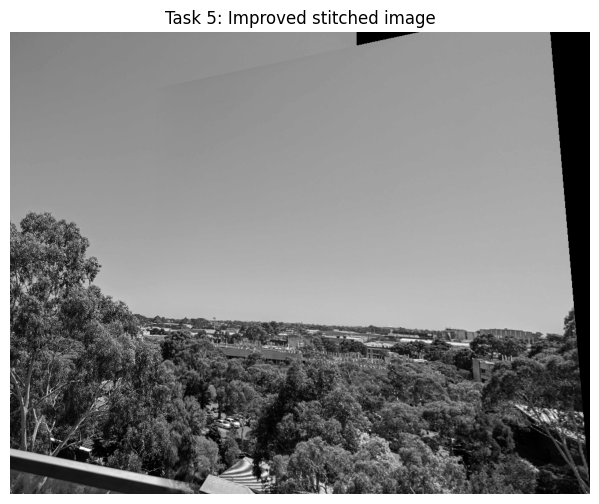

In [ ]:
# Write your code here

def compute_auto_output_width(H_left_to_right, left_shape, right_shape):
    left_h, left_w = left_shape
    right_h, right_w = right_shape

    H_right_to_left = np.linalg.inv(H_left_to_right)

    right_corners = np.array([
        [0, 0, 1],
        [right_w - 1, 0, 1],
        [0, right_h - 1, 1],
        [right_w - 1, right_h - 1, 1]
    ], dtype=np.float64)

    mapped_h = (H_right_to_left @ right_corners.T).T
    mapped_xy = from_homogeneous(mapped_h)

    max_x = max(left_w - 1, np.max(mapped_xy[:, 0]))
    auto_width = int(np.ceil(max_x)) + 1

    return auto_width, mapped_xy

def build_better_blended_stitch(left_img, right_img, H_left_to_right, output_height=800, blend_width=80):
    left_h, left_w = left_img.shape

    auto_width, projected_corners = compute_auto_output_width(
        H_left_to_right, left_img.shape, right_img.shape
    )

    warped_right, valid_right = R_to_L_coords(
        right_img, H_left_to_right, auto_width, output_height
    )

    left_extended = np.zeros((output_height, auto_width), dtype=np.float64)
    left_extended[:left_h, :left_w] = left_img

    overlap_mask = np.zeros_like(valid_right)
    overlap_mask[:, :left_w] = valid_right[:, :left_w]

    if np.any(overlap_mask):
        left_mean = np.mean(left_extended[overlap_mask])
        right_mean = np.mean(warped_right[overlap_mask])
        brightness_scale = left_mean / right_mean if right_mean > 0 else 1.0
    else:
        brightness_scale = 1.0

    brightness_scale = np.clip(brightness_scale, 0.7, 1.3)
    warped_right_scaled = np.clip(warped_right * brightness_scale, 0, 255)

    overlap_columns = np.where(np.any(overlap_mask, axis=0))[0]
    if len(overlap_columns) > 0:
        overlap_start = int(overlap_columns[0])
        seam_x = overlap_start + 20
        seam_x = min(seam_x, left_w - blend_width - 1)
        seam_x = max(0, seam_x)
    else:
        seam_x = left_w

    output = np.zeros((output_height, auto_width), dtype=np.float64)
    output[valid_right] = warped_right_scaled[valid_right]

    left_only_end = min(seam_x, left_w)
    output[:left_h, :left_only_end] = left_img[:, :left_only_end]

    blend_end = min(seam_x + blend_width, left_w)
    if blend_end > seam_x:
        alpha = np.linspace(1.0, 0.0, blend_end - seam_x, endpoint=True)[None, :]

        left_strip = left_img[:, seam_x:blend_end].astype(np.float64)
        right_strip = warped_right_scaled[:, seam_x:blend_end]
        right_valid_strip = valid_right[:, seam_x:blend_end]

        blended_strip = alpha * left_strip + (1.0 - alpha) * right_strip
        output[:left_h, seam_x:blend_end] = np.where(
            right_valid_strip, blended_strip, left_strip
        )

    rem_start = min(blend_end, left_w)
    rem_end = left_w
    if rem_end > rem_start:
        invalid_remaining = ~valid_right[:, rem_start:rem_end]
        output[:left_h, rem_start:rem_end][invalid_remaining] = (
            left_img[:, rem_start:rem_end][invalid_remaining]
        )

    nonzero_columns = np.where(np.any(output > 0, axis=0))[0]
    if len(nonzero_columns) > 0:
        final_width = int(nonzero_columns[-1]) + 1
    else:
        final_width = auto_width

    output = np.clip(output[:, :final_width], 0, 255).astype(np.uint8)

    info = {
        'auto_width': auto_width,
        'final_width': final_width,
        'brightness_scale': float(brightness_scale),
        'seam_x': int(seam_x),
        'blend_width': int(blend_width),
        'projected_corners_in_left_coords': projected_corners
    }

    return output, info

stitched_better, blend_info = build_better_blended_stitch(
    left_img, right_img, H, output_height=800, blend_width=80
)

print("Task 5 blending information:")
for key, value in blend_info.items():
    print(f"{key}: {value}")

plt.figure(figsize=(12, 6))
plt.imshow(stitched_better, cmap='gray')
plt.title('Task 5: Improved stitched image')
plt.axis('off')
plt.show()

In [11]:
# Show results here





# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

In [12]:
# Write your code here

In [13]:
# Show results here





# Discussion:

Write a brief (600 word max) report describing how you solved each task, interpreting the results and pointing to any insights gained along the way. For example, you may wish to explain what a homography is, the conditions under which it can be used. Analyse the stitched images and explain any interesting artifacts you may see and why these occur. You should discuss the reasons for the presence of the image seam, and the strategies you used to improve this, pointing to the theory you have learned in class that guided your solution. Finally, explain any changes you made to the code to apply it to your own images. 

